# Train DeepONet on SNI A/B/C METIS subdomains

Run `generate_sni_eval_metis.ipynb` first. This notebook loads its saved variable-size subdomains, fits training-only normalizers, trains the existing point-set DeepONet, saves the best checkpoint, and evaluates each geometry separately.

In [1]:
%load_ext autoreload
%autoreload 2

from datetime import datetime
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

MODULE_DIR = Path.cwd()
if not (MODULE_DIR / 'sni_eval_dataset.py').exists():
    MODULE_DIR = MODULE_DIR / 'DeepONet'
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from fluent_deeponet import (
    DeepONet, FeatureNormalizer, evaluate_deeponet, train_deeponet_one_epoch,
)
from sni_eval_dataset import (
    SNIEvalSubdomainDataset, load_sni_eval_dataset_h5, sni_eval_collate_fn,
)

## Training configuration

In [2]:
DATA_DIR = MODULE_DIR / 'data' / 'sni_eval_metis'
TRAIN_PATH = DATA_DIR / 'train.h5'
VALID_PATH = DATA_DIR / 'valid.h5'
TEST_PATH = DATA_DIR / 'test.h5'

SEED = 0
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
EPOCHS = 1000
BATCH_SIZE = 32
N_QUERY_TRAIN = None  # set to 64/128/... for stochastic query subsampling
N_QUERY_VALID = None
LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 1.0e-4
LATENT_DIM = 128
HIDDEN_DIM = 128
LOG_EVERY = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('Device:', DEVICE)

Device: cuda:0


## Load datasets and inspect their layout

In [3]:
train_data = load_sni_eval_dataset_h5(TRAIN_PATH)
valid_data = load_sni_eval_dataset_h5(VALID_PATH)
test_data = load_sni_eval_dataset_h5(TEST_PATH)

print('PDE:', train_data['pde_name'])
print('Train/valid/test:', len(train_data['samples']), len(valid_data['samples']), len(test_data['samples']))
print('Branch channels:', train_data['branch_channel_names'])
print('Output channels:', train_data['output_channel_names'])
print('First branch/query/target:',
      train_data['samples'][0]['branch'].shape,
      train_data['samples'][0]['query'].shape,
      train_data['samples'][0]['target'].shape)

PDE: laplace2d
Train/valid/test: 6000 750 750
Branch channels: ['x_local', 'y_local', 'input_0_mask', 'interface_mask', 'payload_0', 'payload_1', 'payload_0_valid', 'payload_1_valid', 'local_aspect_ratio']
Output channels: ['solution_0']
First branch/query/target: (58, 9) (145, 2) (145, 1)


## Fit normalizers using only training data

In [4]:
def concatenate(samples, key):
    return np.concatenate([sample[key] for sample in samples], axis=0).astype(np.float32)

branch_names = train_data['branch_channel_names']
skip_branch = [
    i for i, name in enumerate(branch_names)
    if name in {'x_local', 'y_local'} or name.endswith('_mask') or name.endswith('_valid')
]
branch_normalizer = FeatureNormalizer(
    concatenate(train_data['samples'], 'branch'), skip_indices=skip_branch
)
target_normalizer = FeatureNormalizer(concatenate(train_data['samples'], 'target'))
target_normalizer_device = FeatureNormalizer.from_state_dict(
    target_normalizer.state_dict()
).to(DEVICE)

print('Target mean:', target_normalizer.mean)
print('Target std:', target_normalizer.std)

Target mean: tensor([0.4983])
Target std: tensor([0.1469])


## DataLoaders

In [5]:
def make_dataset(data, n_query_points, random_query):
    return SNIEvalSubdomainDataset(
        data['samples'],
        branch_normalizer=branch_normalizer,
        target_normalizer=target_normalizer,
        n_query_points=n_query_points,
        random_query=random_query,
    )

train_dataset = make_dataset(train_data, N_QUERY_TRAIN, True)
valid_dataset = make_dataset(valid_data, N_QUERY_VALID, False)
test_dataset = make_dataset(test_data, N_QUERY_VALID, False)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator,
    collate_fn=sni_eval_collate_fn,
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=sni_eval_collate_fn,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=sni_eval_collate_fn,
)

branch, query, target, query_batch_id, sample_index, branch_mask = next(iter(train_loader))
print('Batch:', branch.shape, query.shape, target.shape, branch_mask.shape)

Batch: torch.Size([32, 109, 9]) torch.Size([4881, 2]) torch.Size([4881, 1]) torch.Size([32, 109])


## Model and optimizer

In [6]:
first = train_data['samples'][0]
model = DeepONet(
    branch_input_dim=first['branch'].shape[1],
    trunk_input_dim=first['query'].shape[1],
    output_channels=first['target'].shape[1],
    latent_dim=LATENT_DIM,
    branch_point_hidden_dim=HIDDEN_DIM,
    branch_global_hidden_dim=HIDDEN_DIM,
    trunk_hidden_dim=HIDDEN_DIM,
    aggregation='mean',
).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print(model.config())

{'branch_input_dim': 9, 'trunk_input_dim': 2, 'output_channels': 1, 'latent_dim': 128, 'branch_point_hidden_dim': 128, 'branch_point_depth': 3, 'branch_global_hidden_dim': 128, 'branch_global_depth': 3, 'trunk_hidden_dim': 128, 'trunk_depth': 4, 'aggregation': 'mean', 'activation': 'gelu', 'layer_norm': False}


## Train and save the best checkpoint

In [7]:
stamp = datetime.now().strftime('sni_metis_%m%d%y_%H%M%S')
OUTPUT_DIR = MODULE_DIR / 'results' / stamp
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = OUTPUT_DIR / 'checkpoint.pt'

best_valid_mse = float('inf')
history = []
for epoch in range(1, EPOCHS + 1):
    train_mse, _, _ = train_deeponet_one_epoch(
        model=model, loader=train_loader, optimizer=optimizer, device=DEVICE,
        lambda_bc=0.0, lambda_pde=0.0,
    )
    scheduler.step()
    metrics = evaluate_deeponet(
        model, valid_loader, DEVICE, y_normalizer=target_normalizer_device
    )
    row = {
        'epoch': epoch,
        'train_mse_normalized': train_mse,
        'valid_mse': float(metrics['mse']),
        'valid_relative_l2': float(metrics['relative_l2']),
    }
    history.append(row)

    if row['valid_mse'] < best_valid_mse:
        best_valid_mse = row['valid_mse']
        torch.save({
            'model_state_dict': model.state_dict(),
            'model_config': model.config(),
            'branch_normalizer': branch_normalizer.state_dict(),
            'y_normalizer': target_normalizer_device.state_dict(),
            'branch_channel_names': train_data['branch_channel_names'],
            'trunk_channel_names': train_data['trunk_channel_names'],
            'output_channel_names': train_data['output_channel_names'],
            'pde_name': train_data['pde_name'],
            'train_data': str(TRAIN_PATH),
            'valid_data': str(VALID_PATH),
            'epoch': epoch,
            'valid_metrics': row,
        }, CHECKPOINT_PATH)

    if epoch == 1 or epoch % LOG_EVERY == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:04d} | train={train_mse:.3e} | "
              f"valid MSE={row['valid_mse']:.3e} | "
              f"valid rel L2={row['valid_relative_l2']:.3e}")

np.savez(
    OUTPUT_DIR / 'loss_history.npz',
    epoch=np.asarray([row['epoch'] for row in history]),
    train_mse_normalized=np.asarray([row['train_mse_normalized'] for row in history]),
    valid_mse=np.asarray([row['valid_mse'] for row in history]),
    valid_relative_l2=np.asarray([row['valid_relative_l2'] for row in history]),
)
print('Best validation MSE:', best_valid_mse)
print('Checkpoint:', CHECKPOINT_PATH)

Epoch 0001 | train=1.011e+00 | valid MSE=2.126e-02 | valid rel L2=2.638e-01
Epoch 0010 | train=9.910e-01 | valid MSE=2.110e-02 | valid rel L2=2.624e-01
Epoch 0020 | train=9.457e-01 | valid MSE=2.031e-02 | valid rel L2=2.567e-01
Epoch 0030 | train=8.799e-01 | valid MSE=1.909e-02 | valid rel L2=2.481e-01
Epoch 0040 | train=8.328e-01 | valid MSE=1.832e-02 | valid rel L2=2.422e-01
Epoch 0050 | train=8.010e-01 | valid MSE=1.776e-02 | valid rel L2=2.379e-01
Epoch 0060 | train=7.767e-01 | valid MSE=1.727e-02 | valid rel L2=2.341e-01
Epoch 0070 | train=7.543e-01 | valid MSE=1.707e-02 | valid rel L2=2.322e-01
Epoch 0080 | train=7.373e-01 | valid MSE=1.656e-02 | valid rel L2=2.284e-01
Epoch 0090 | train=7.216e-01 | valid MSE=1.637e-02 | valid rel L2=2.271e-01
Epoch 0100 | train=7.082e-01 | valid MSE=1.607e-02 | valid rel L2=2.246e-01
Epoch 0110 | train=6.953e-01 | valid MSE=1.603e-02 | valid rel L2=2.241e-01
Epoch 0120 | train=6.815e-01 | valid MSE=1.572e-02 | valid rel L2=2.216e-01
Epoch 0130 |

## Plot loss history

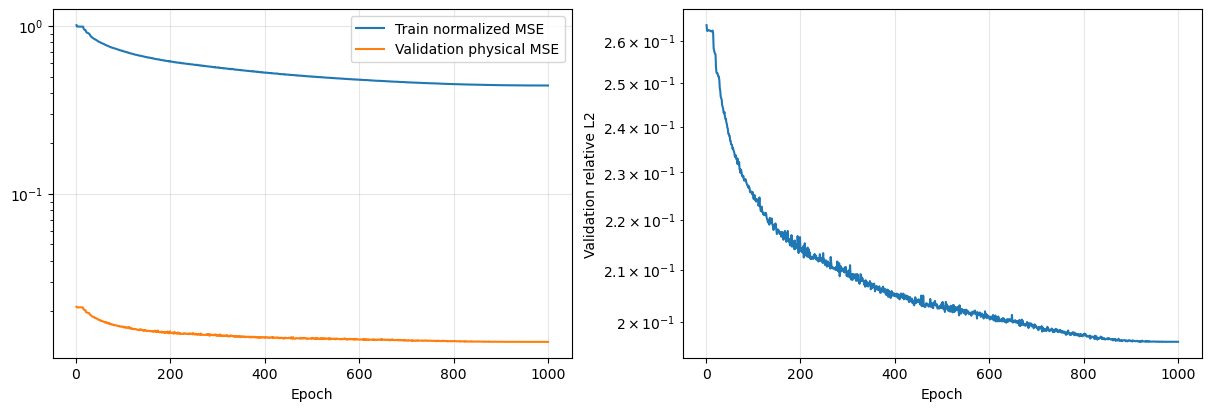

In [8]:
epochs = np.asarray([row['epoch'] for row in history])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(epochs, [row['train_mse_normalized'] for row in history], label='Train normalized MSE')
axes[0].plot(epochs, [row['valid_mse'] for row in history], label='Validation physical MSE')
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(epochs, [row['valid_relative_l2'] for row in history])
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation relative L2')
axes[1].grid(alpha=0.3)
fig.savefig(OUTPUT_DIR / 'loss_history.png', dpi=160)
plt.show()

## Evaluate the best checkpoint on A, B, and C separately

In [9]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
best_model = DeepONet(**checkpoint['model_config']).to(DEVICE)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

for domain in ('A', 'B', 'C'):
    domain_samples = [
        sample for sample, metadata in zip(test_data['samples'], test_data['metadata'])
        if metadata['domain'] == domain
    ]
    domain_dataset = SNIEvalSubdomainDataset(
        domain_samples,
        branch_normalizer=branch_normalizer,
        target_normalizer=target_normalizer,
        n_query_points=N_QUERY_VALID,
        random_query=False,
    )
    domain_loader = DataLoader(
        domain_dataset, batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=sni_eval_collate_fn,
    )
    metrics = evaluate_deeponet(
        best_model, domain_loader, DEVICE, y_normalizer=target_normalizer_device
    )
    print(domain, 'MSE=', metrics['mse'], 'relative L2=', metrics['relative_l2'])

A MSE= 0.005878959659487009 relative L2= 0.1505144466161728
B MSE= 0.008874875463545323 relative L2= 0.17281996750831605
C MSE= 0.02339821754395962 relative L2= 0.2717862434387207


/tmp/ipykernel_95555/1377651442.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
